**GRAFICOS GM/ID**

Plotting NMOS curves...
  Saved: NMOS_IdW_vs_gmId.png


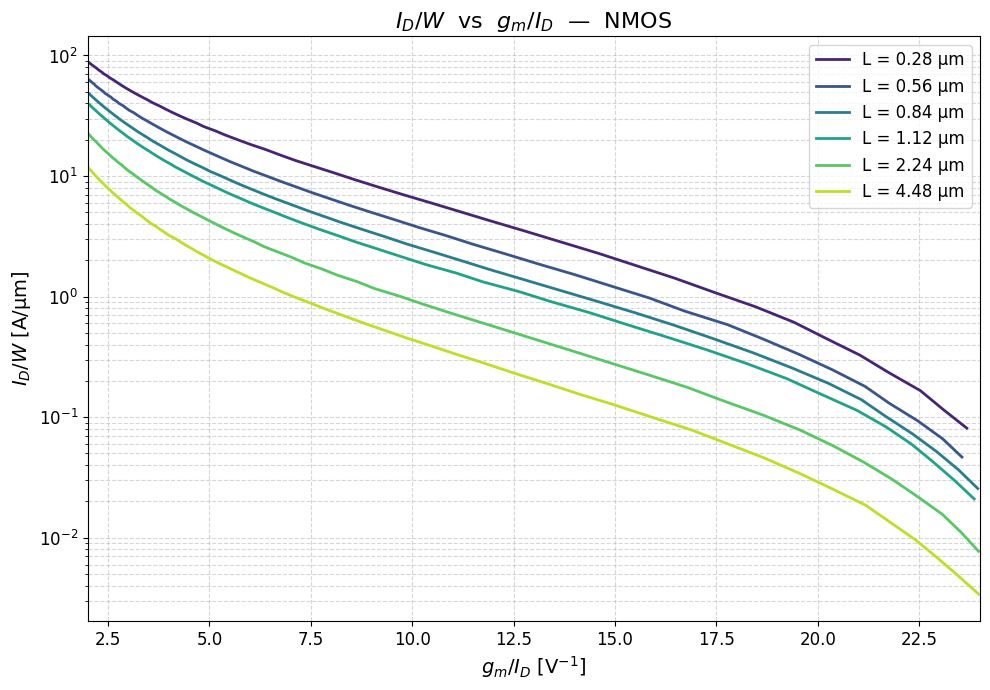


Plotting PMOS curves...
  Saved: PMOS_IdW_vs_gmId.png


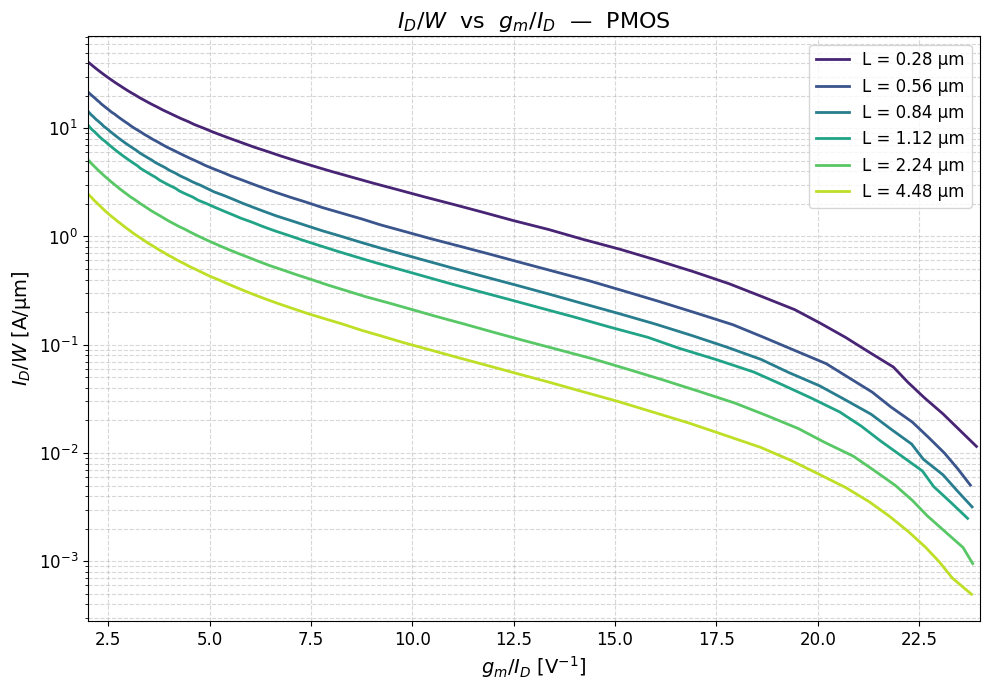


Done!


In [1265]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import numpy as np
import os
import sys

# ── Configuration ──────────────────────────────────────────────────────────
# Map each channel length label to its CSV filename.
# ** ADJUST FILENAMES HERE to match your actual files **

LENGTHS = ["0.28 µm", "0.56 µm", "0.84 µm", "1.12 µm", "2.24 µm", "4.48 µm"]

NMOS_FILES = {
    "0.28 µm": "NMOS/L_0p28u.csv",
    "0.56 µm": "NMOS/L_0p56u.csv",
    "0.84 µm": "NMOS/L_0p84u.csv",
    "1.12 µm": "NMOS/L_1p12u.csv",
    "2.24 µm": "NMOS/L_2p24u.csv",
    "4.48 µm": "NMOS/L_4p48u.csv",
}

PMOS_FILES = {
    "0.28 µm": "PMOS/L_0p28u.csv",
    "0.56 µm": "PMOS/L_0p56u.csv",
    "0.84 µm": "PMOS/L_0p84u.csv",
    "1.12 µm": "PMOS/L_1p12u.csv",
    "2.24 µm": "PMOS/L_2p24u.csv",
    "4.48 µm": "PMOS/L_4p48u.csv",
}

# gm/ID range of interest
GMID_MIN = 2
GMID_MAX = 24

# ── Helper function ────────────────────────────────────────────────────────
def load_and_filter(filepath, gmid_min, gmid_max):
    """Load a CSV and filter rows where gmId is within [gmid_min, gmid_max]."""
    df = pd.read_csv(filepath)
    # Clean column names (strip whitespace)
    df.columns = df.columns.str.strip()
    df = df[(df["gmId"] >= gmid_min) & (df["gmId"] <= gmid_max)]
    return df


def plot_device(file_dict, device_type, gmid_min, gmid_max):
    """
    Plot ID/W vs gm/ID for all channel lengths of a given device type.
    """
    fig, ax = plt.subplots(figsize=(10, 7))

    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(file_dict)))

    for (label, fname), color in zip(file_dict.items(), colors):
        if not os.path.isfile(fname):
            print(f"  [WARNING] File not found: {fname}  — skipping L = {label}")
            continue

        df = load_and_filter(fname, gmid_min, gmid_max)

        ax.semilogy(df["gmId"], df["IdW"],
                     label=f"L = {label}",
                     color=color, linewidth=2)

    ax.set_xlabel(r"$g_m / I_D$ [V$^{-1}$]", fontsize=14)
    ax.set_ylabel(r"$I_D / W$ [A/µm]", fontsize=14)
    ax.set_title(f"$I_D/W$  vs  $g_m/I_D$  —  {device_type}", fontsize=16)
    ax.set_xlim(gmid_min, gmid_max)
    ax.legend(fontsize=12, loc="best")
    ax.grid(True, which="both", ls="--", alpha=0.5)
    ax.tick_params(labelsize=12)

    plt.tight_layout()
    outname = f"{device_type}_IdW_vs_gmId.png"
    print(f"  Saved: {outname}")
    plt.show()


# ── Main ───────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("Plotting NMOS curves...")
    plot_device(NMOS_FILES, "NMOS", GMID_MIN, GMID_MAX)

    print("\nPlotting PMOS curves...")
    plot_device(PMOS_FILES, "PMOS", GMID_MIN, GMID_MAX)

    print("\nDone!")

In [1266]:
def build_param_interpolators(file_dict, param):
    """Construye interpoladores cúbicos gm/ID -> param para cada largo de canal."""
    interpolators = {}
    for label, fname in file_dict.items():
        if not os.path.isfile(fname):
            print(f"  [WARNING] Archivo no encontrado: {fname} — saltando L = {label}")
            continue
        df = load_and_filter(fname, GMID_MIN, GMID_MAX)
        df = df.drop_duplicates(subset="gmId").sort_values("gmId")
        interpolators[label] = interp1d(
            df["gmId"].values, df[param].values,
            kind="cubic", fill_value="extrapolate"
        )
    return interpolators


def lookup_param(gmid_value, device_type, param, length=None):
    """
    Retorna el valor interpolado de un parámetro (Vov, VTH, etc.) para un gm/ID dado.

    Parámetros:
        gmid_value  : float  - valor de gm/ID (entre 2 y 24)
        device_type : str    - "NMOS" o "PMOS"
        param       : str    - nombre de la columna en el CSV (ej: "Vov", "VTH")
        length      : str    - ej: "1.12 µm", o None para todos los largos

    Retorna:
        dict : {largo: valor}
    """
    file_dict = NMOS_FILES if device_type.upper() == "NMOS" else PMOS_FILES
    interpolators = build_param_interpolators(file_dict, param)

    results = {}
    targets = [length] if length else interpolators.keys()
    for L in targets:
        if L in interpolators:
            results[L] = float(interpolators[L](gmid_value))
    return results

**Sizing del par**

In [1267]:
# c_l = 100e-15 
# gm_pair = 2 * np.pi * 20e6 * 1.1* c_l    
# gm_pair = 2.38e-5
# I_pair = 1e-6
# gm_id_pair =  gm_pair / I_pair
# L_pair = "1.12 µm"

# ID_pair = gm_pair / gm_id_pair    
# Iss     = 2 * ID_pair            
# print(f"gm_pair = {gm_pair:.2e} S")   
# print(f"gm/ID = {gm_id_pair:.2f} V^-1")
# print(f"Iss = {Iss*1e6:.2f} µA")

c_l = 100e-15 
gm_pair = 2 * np.pi * 20e6 * 1.9* c_l    
# gm_pair = 10 * 2.38e-5
I_pair = 1e-6
gm_id_pair =  gm_pair / I_pair
L_pair = "0.28 µm"

ID_pair = gm_pair / gm_id_pair    
Iss     = 2 * ID_pair            
print(f"gm_pair = {gm_pair:.2e} S")   
print(f"gm/ID = {gm_id_pair:.2f} V^-1")
print(f"Iss = {Iss*1e6:.2f} µA")

gm_pair = 2.39e-05 S
gm/ID = 23.88 V^-1
Iss = 2.00 µA


In [1268]:
# para el par diferencial
idw_pair = lookup_param(gm_id_pair, "NMOS", "IdW",L_pair)[L_pair]
print(f"gm/ID = {gm_id_pair:.2f} V^-1")
print(f"ID/W = {idw_pair} A/µm")

w_pair = (Iss/2) / idw_pair
print(f"w={w_pair*1e6} um")

gm/ID = 23.88 V^-1
ID/W = 0.07928872844270415 A/µm
w=12.612133144783911 um


In [1269]:
# extraemos los Vov
vov_pair = lookup_param(gm_id_pair, "NMOS", "Vov",L_pair)[L_pair]
print(f"Vov pair = {vov_pair} V")

# extraemos los vth
vth_pair = lookup_param(gm_id_pair, "NMOS", "Vth",L_pair)[L_pair]
print(f"Vth pair = {vth_pair} V")

Vov pair = -0.1402251891706367 V
Vth pair = 0.6472501155737751 V


**Sizing del transistor de cola**

In [1270]:
gm_id_tail = 8
L_tail     = "4.48 µm"
idw_tail   = lookup_param(gm_id_tail, "NMOS", "IdW", L_tail)[L_tail]
W_tail     = Iss / idw_tail
print(f"W_M11 = {W_tail*1e6:.2f} µm,  W_Mb1 = {4*W_tail*1e6:.2f} µm")

W_M11 = 2.64 µm,  W_Mb1 = 10.56 µm


In [1271]:
# extraemos los Vov
vov_tail = lookup_param(gm_id_tail, "NMOS", "Vov",L_tail)[L_tail]
print(f"Vov tail = {vov_tail} V")

# extraemos los vth
vth_tail = lookup_param(gm_id_tail, "NMOS", "Vth",L_tail)[L_tail]
print(f"Vth tail = {vth_tail} V")

Vov tail = 0.21117098918182883 V
Vth tail = 0.656 V


In [1272]:
vov_pair + vth_pair + vov_tail

0.7181959155849672

**Sizing transistores rama cascodo**

In [1273]:
12*0.3e-6

3.6e-06

In [ ]:
Ifold = 3e-6
Icas = 2e-6
gm_id_current = 12
gm_id_cas = 14

L_mirror = "2.24 µm"
L_cas = "0.84 µm"

idw_m5 = lookup_param(gm_id_current, "PMOS", "IdW", L_mirror)[L_mirror]
W_m5   = Ifold / idw_m5
# PMOS cascode M3 (2 µA)
idw_m3 = lookup_param(gm_id_cas, "PMOS", "IdW", L_cas)[L_cas]
W_m3   = Icas / idw_m3
# NMOS cascode M7 (2 µA)
idw_m7 = lookup_param(gm_id_cas, "NMOS", "IdW", L_cas)[L_cas]
W_m7   = Icas / idw_m7
# NMOS sink M9 (2 µA)
idw_m9 = lookup_param(gm_id_current, "NMOS", "IdW", L_mirror)[L_mirror]
W_m9   = Icas / idw_m9
print(W_m5*1e6, W_m3*1e6, W_m7*1e6, W_m9*1e6)

86.21145305166034 18.736372022359532 4.5336271451395795 12.65588156971946


In [1275]:
print(gm_id_current*Ifold)

0.00024


In [1276]:
vov_m5 = lookup_param(gm_id_current, "PMOS", "Vov", L_mirror)[L_mirror]
vov_m3 = lookup_param(gm_id_cas, "PMOS", "Vov", L_cas)[L_cas]
vov_m7 = lookup_param(gm_id_cas, "NMOS", "Vov", L_cas)[L_cas]
vov_m9 = lookup_param(gm_id_current, "NMOS", "Vov", L_mirror)[L_mirror]
print(vov_m5, vov_m3, vov_m7, vov_m9)

0.21758524772884405 0.21638696724530201 0.20034920504151887 0.20863681588722385


In [1277]:
vth_m5 = lookup_param(gm_id_current, "PMOS", "Vth", L_mirror)[L_mirror]
vth_m3 = lookup_param(gm_id_cas, "PMOS", "Vth", L_cas)[L_cas]
vth_m7 = lookup_param(gm_id_cas, "NMOS", "Vth", L_cas)[L_cas]
vth_m9 = lookup_param(gm_id_current, "NMOS", "Vth", L_mirror)[L_mirror]
print(vth_m5, vth_m3, vth_m7, vth_m9)

-0.7739999999999999 -0.7869999999999999 0.6930000000000001 0.667


**Cascode branch bias voltages**

Del .op obtenemos que Vdsat_m9 = 0.144 y que Vdsat_m7=0.115 y Vth_m7=0.734

In [1278]:
0.115+0.734+0.144

0.993

Del .op obtenemos que Vdsat_m5 = 0.157 y que Vdsat_m7=0.121 y Vth_m7=0.813

In [1279]:
3.3 - (0.157+0.121+0.813)

2.2089999999999996

In [1280]:
vb1 = vov_m7 + vth_m7 + vov_m9
vb1

1.1019860209287429

In [1281]:
vb2 = 3.3 - (abs(vov_m5) + abs(vth_m5)) - abs(vov_m3)
vb2

2.092027785025854

In [1282]:
abs(vov_m5) + abs(vov_m9)

0.4262220636160679

In [1283]:
10**(80/20) * 3.74e3 / 1e6

37.4

In [1284]:
(3.3-2)/12e-6

108333.33333333331

**Design of the copy current transistors**

In [1285]:
gm_id_tail = 8
L_copy    = "4.48 µm"
I_copy = 6e-6
idw_copy   = lookup_param(gm_id_tail, "PMOS", "IdW", L_copy)[L_copy]
W_copy     = I_copy / idw_copy
print(f"W_M11 = {W_copy*1e6:.2f} µm")

W_M11 = 35.91 µm


GBW 

**OTA V3**
Two branch current mirror 

P_ota = 100uW

In [1286]:
Av = 10**(66.4747/20)
bw = 13887.1
gbw = Av * bw
gbw/1e6

29.264867547140724

In [1287]:
5.79039e-05

5.79039e-05

## **OTA V4**
Two branch current mirror 

### 1. GBW

In [1288]:
Av_db = 67.4816
Av = 10**(Av_db/20)
bw = 13878.6
gbw = Av * bw
gbw/1e6

32.84170222148242

### 2. CMRR

In [1289]:
Av_dc_dc = - 95.91
cmrr = Av_db - Av_dc_dc
cmrr

163.39159999999998

### 3. PSRR

In [1290]:
Av_dc_dm = 20 * np.log10(1.30861e-13)
Av_vdd_dm = 20 * np.log10(3.51566e-12)
psrr = Av_db - Av_vdd_dm
psrr

np.float64(296.5614626450241)

### 4. SNR

In [1291]:
Vo_swing = 2.5
pn_rms  = 0.1
snr = 20 * np.log10((Vo_swing/np.sqrt(2)) / pn_rms)
snr

np.float64(24.948500216800937)

## Calculos a mano

In [1292]:
def par(x, y):
    return 1 / (1/x + 1/y)

def ro(id, lamb=0.2):
    return 1 / (lamb * id)

def gm(id, vov):
    return abs(2*id/vov)

def gain(gm1, gm2, gm4, ro1, ro2, ro3, ro4, ro5):
    return gm1 * par(gm2*ro2*par(ro1,ro3), gm4*ro4*ro5)

### 1. Av_cm-dm: Ganancia diferencial

In [1293]:
gm1 = gm(ID_pair, vov_pair)
gm2 = gm(ID_pair, vov_m3)
gm3 = gm(Ifold, vov_m5)
gm4 = gm(Icas, vov_m7)
gm5 = gm(Icas, vov_m9)
ro1 = ro(ID_pair)
ro2 = ro(Icas)
ro3 = ro(Ifold)
ro4 = ro(Icas)
ro5 = ro(Icas)


Av_teorico = gain(gm1, gm2, gm4, ro1, ro2, ro3, ro4, ro5)
print(f"Av_teorico = {Av_teorico}")
print(f"Av_db = {20 * np.log10(Av_teorico)}")


Av_teorico = 5.161428789667185
Av_db = 14.255398798337286


### 2. Bandwidth

In [1294]:
def Cgd(W, Cov=0.1e-15):
    """Calculate the gate capacitance of a MOSFET.

    Parameters
    ----------
    W : float
        The width of the MOSFET in meters.
    Cov : float, optional
        The overlap capacitance per unit width in farads per meter. Default is 0.1 fF/um.

    Returns
    -------
    float
        The gate capacitance in farads.
    """
    return Cov * W

def Cgs(W, L, Cox=4.4e-15, Cov=0.1e-15):
    """Calculate the gate-to-source capacitance of a MOSFET.

    Parameters
    ----------
    W : float
        The width of the MOSFET in meters.
    L : float
        The length of the MOSFET in meters.
    Cox : float, optional
        The oxide capacitance per unit area in farads per square meter. Default is 4.4 fF/um^2.
    Cov : float, optional
        The overlap capacitance per unit width in farads per meter. Default is 0.1 fF/um.

    Returns
    -------
    float
        The gate-to-source capacitance in farads.
    """
    return (2/3)* Cox * W * L + Cov * W

In [1295]:
# Cgs1
Ro = par(gm2*ro2*par(ro1,ro3), gm4*ro4*ro5)
CL = 100e-15
tau = Ro * CL
bw = 1 / (2 * np.pi * tau)
Ro/1e6

0.3618811642109257

In [1296]:
gbw_teorico = Av_teorico * bw
print(f"GBW teórico = {gbw_teorico/1e6} MHz")

GBW teórico = 22.69990777451881 MHz


### 3. Potencia

#### 3.1. OTA V4
Tenemos 6 ramas de corriente con master branch y los espejos de 6uA y la rama de los cascodos 3uA

In [1297]:
Vdd = 3.3
Itot = 4 * 6e-6 + 2 * 3e-6
Ptot = Vdd * Itot
print(f"Ptot = {Ptot*1e6} µW")

Ptot = 99.0 µW


#### 3.2. OTA V2
Tenemos 8 ramas de corriente con master branch de 500nA y los espejos de 2uA (3 ramas) y 1uA (2 ramas) y la rama de los cascodos 3uA (2 ramas)

In [1298]:
Vdd = 3.3
Itot_v2 = 1 * 500e-9 + 3*2e-6 + 2*1e-6 + 2 * 3e-6
Ptot_v2 = Vdd * Itot_v2
print(f"Ptot = {Ptot_v2*1e6} µW")

Ptot = 47.849999999999994 µW


## 4. Excursion de salida

In [1299]:
vo_min = vov_m9 + vov_m7
vo_max = Vdd - (abs(vov_m5) + abs(vov_m3))
print(f"Rango de salida: {vo_min:.2f} V a {vo_max:.2f} V")
print(f"swing: {vo_max - vo_min:.2f} V")

Rango de salida: 0.41 V a 2.87 V
swing: 2.46 V


In [1300]:
Vswinger = 2 * min(abs(1.65-vo_min), abs(1.65 - vo_max))
Vswinger

2.432055570051708

## 6. PSRR 

In [1301]:
Rcas = gm4*ro4*ro5

Avdd = (1/ro3) * par(Rcas, par(Rcas,ro2) * par(ro1,ro2) * gm2)**-1
Avdd_db = 20 * np.log10(Avdd)
print(f"Avdd = {Avdd_db:.2f} dB")
print(f"PSRR = {20*np.log10(Av_teorico) - Avdd_db:.2f} dB")

Avdd = -218.71 dB
PSRR = 232.96 dB


## 5. CMRR 

In [1302]:
r_tail = ro(Iss)
Acm = Ro / (2*r_tail) 
20*np.log10(Acm)

np.float64(-22.808080510333895)

In [1303]:
20*np.log10(Av_teorico) - 20*np.log10(Acm)

np.float64(37.06347930867118)

## 6. SNR 

In [1304]:
def inoise_folded_cas(gm1, gm3, gm5):
    k = 1.38e-23
    T = 300
    gamma = 2/3
    return (4*k*T*gamma/gm1) * (1 + gm3/gm1 + gm5/gm1)

In [1305]:
onoise = inoise_folded_cas(gm1, gm3, gm5) * Av_teorico**2
print(f"onoise = {onoise * 20e3 * 1e6} uV^2")

onoise = 0.013929690345817617 uV^2


In [1306]:
def inoise_folded_cas(gm1, gm3, gm5):
    k = 1.38e-23
    T = 300
    gamma = 2/3
    return (4*k*T*gamma/gm1) * (1 + gm3/gm1 + gm5/gm1)

def onoise_rms_folded_cas(gm1, gm3, gm5, Av_teorico, fp):
    import numpy as np
    inoise = inoise_folded_cas(gm1, gm3, gm5)
    onoise_psd = inoise * Av_teorico**2
    return np.sqrt(onoise_psd * (np.pi/2) * fp)

# Usage
onoise = inoise_folded_cas(gm1, gm3, gm5) * Av_teorico**2
onoise_rms = onoise_rms_folded_cas(gm1, gm3, gm5, Av_teorico, bw)
onoise_rms

np.float64(0.002193525806706931)

In [1307]:
snr = 20 * np.log10((Vswinger/np.sqrt(2)) / onoise_rms)
snr

np.float64(57.88631495716356)

In [1308]:
(2.31 - 2.035)/6e-6

45833.333333333314

In [1309]:
1/100e-9 / 1e6

10.0

# PARTE 2.

## 1. Margen de fase 

Frecuencia de crossover y margen de fase obtenidos de la simulacion para buffer

In [1310]:
fc_sim = 2.09775e7
wc_sim = 2 * np.pi * fc_sim 
phase_sim = -105.648


pm_sim = 180 - abs(phase_sim)

print(f"fc = {fc_sim/1e6} MHz")
print(f"PM = {pm_sim} deg")

fc = 20.9775 MHz
PM = 74.352 deg


### Parametros de los transistores 

In [1311]:
## M1, M2
gm_pair = 2.55e-5
gds_pair = 9.96e-7
ro_pair = 1/gds_pair
cbd_pair = 8.34e-15
cbs_pair = 1.03e-14
cgs_pair = 1.04e-14
cgg_pair = 1.63247e-14
cgd_pair = 3.41331e-15

## M13, M17
gm_fold  = 3.31e-5
gds_fold = 5.06e-6
ro_fold = 1/gds_fold
cbd_fold = 2.13e-14
cbs_fold = 2.05e-14
cgs_fold = 1.68212e-13 
cgg_fold = 1.71513e-13 
cgd_fold = 3.30088e-15 

## M14, M18
gm_p  = 2.83e-5
gds_p = 4.40e-8
ro_p = 1/gds_p

cbd_p = 7.15e-15
cbs_p = 5.70e-15
cgs_p = 2.29282e-14 
cgg_p = 2.40663e-14
cgd_p = 1.13808e-15

## M15, M19
gm_ncas  = 2.75e-5
gds_ncas = 8.58e-8
ro_ncas = 1/gds_ncas
cbd_ncas = 1.61e-15
cbs_ncas = 2.10e-15
cgs_ncas = 5.17478e-15
cgg_ncas = 5.46119e-15
cgd_ncas = 2.8641e-16

## M16, M20-
gm_sink  = 1.48e-5
gds_sink = 1.48e-6
cbd_sink = 2.65e-15
cbs_sink = 2.78e-15


gm_ctr = 6.54e-6
gds_ctr = 9.75e-7
cbd_ctr = 1.24e-15
cbs_ctr = 1.30e-15

ro_down = par(1/gds_ctr, 1/gds_sink)
gm_down = gm_sink + gm_ctr

cgs_sink = 2.46156e-14
cgg_sink = 2.51421e-14
cgd_sink = 5.26469e-16



### Calculamos la frecuencia de crossover para configuracion buffer

In [1312]:
# Capacitancia de entrada al OTA
Cin = cgs_pair + (1 + gm_pair/gm_p) * cgd_pair

# Capacitores del CMFB
C1_cmfb = 20e-15
C2_cmfb = C1_cmfb / 10
C_cmfb = C1_cmfb + C2_cmfb

# Capacitancia efectiva vista a la salida
CL_eff = CL + C_cmfb + (cbd_ncas + cgd_ncas) + (cbd_p + cgd_p) + Cin 

print(f"CL_eff = {CL_eff*1e15} fF")

CL_eff = 149.07339734982332 fF


In [1313]:
wc = gm_pair / CL_eff
fc = wc / (2 * np.pi)

print(fc/1e6)
print(fc_sim/1e6)

27.224515715031036
20.9775


### Calculamos el polo dominante (nodo Vo)

In [1314]:
# Ro = par(gm2*ro2*par(ro1,ro3), gm4*ro4*ro5)
Ro = par((gm_ncas * ro_ncas * ro_down), gm_p * ro_p * par(ro_pair, ro_fold))
wp1 = 1/(Ro * CL_eff)
fp1 = wp1 / (2*np.pi)
fp1/1e3

18.230057841952654

### Calculamos los polos producto a los nodos intermedios

In [1315]:
Cx = cbd_pair + cgd_pair + cbd_fold + cgd_fold + cgs_p + cbs_p
Rx = 1/gm_p

wpx = 1 / (Rx * Cx)
fpx = wpx / (2*np.pi)
fpx/1e6

69.31239201113776

In [1316]:
Cz = (cgs_ncas + cbs_ncas) + cbd_sink + cgd_sink/2 + cbd_ctr + cgd_sink/2
Rz = 1/gm_ncas

wpz = 1 / (Rz * Cz)
fpz = wpz / (2*np.pi)
fpz/1e6

374.36213487772966

### Calculamos el margen de fase teorico

In [1317]:
pm = np.pi - (np.arctan(wc / wp1) +  np.arctan(wc / wpx) + np.arctan(wc / wpz))
pm_deg = pm*180/np.pi

print(f"PM = {pm_deg} deg")

PM = 64.43509814697626 deg


### Calculo de beta, CF y CS

In [1318]:
beta = 0.7
Cin = cgs_pair + (1 + gm_pair/gm_fold) * cgd_pair
Cs = 20e-15
Cf = 91e-15

print(Cin)

Cf / (Cf + Cs + Cin)

1.644289927492447e-14


0.7140452745326475